In [ ]:
# 2026-Sept-12 
# Customer Segmentations with kMeans using with Python

In [53]:
# importing libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
import sklearn.preprocessing
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


In [16]:
# import file
custsales = pd.read_csv("Customer Segments.csv")
print(custsales.head())

   Cust_ID  Age  BillAmt_Product  BillAmt_Service  BillAmt_Pre  Vintage
0    82078   49         81128.27         48203.10     62975.45      5.0
1    57215   34         59480.20         17263.19     23633.58      5.0
2    66970   58         65363.07         30660.67     45888.87      6.0
3    77319   48         84073.28         47181.46     43186.04      7.0
4    29564   26         10541.03          3550.96     12753.15      1.0


In [19]:
rows, columns = custsales.shape
print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 24024
Number of columns: 6


In [20]:
# Removing the NA's
custsales = custsales.dropna()

In [25]:
# Subset data by deleting CustomerID for clustering
custsales_cl = custsales.drop(columns=['Cust_ID'])
print(custsales_cl.head())                        

   Age  BillAmt_Product  BillAmt_Service  BillAmt_Pre  Vintage
0   49         81128.27         48203.10     62975.45      5.0
1   34         59480.20         17263.19     23633.58      5.0
2   58         65363.07         30660.67     45888.87      6.0
3   48         84073.28         47181.46     43186.04      7.0
4   26         10541.03          3550.96     12753.15      1.0


In [26]:
# Standarise all variables using scale function
df_scaled = sklearn.preprocessing.scale(custsales_cl)
df_scaled

array([[ 0.75455685,  1.19283766,  1.83500523,  1.65449965,  0.55744769],
       [-0.46048874,  0.46615231, -0.16445267, -0.47888889,  0.55744769],
       [ 1.4835842 ,  0.66362929,  0.70134484,  0.727947  ,  0.97034198],
       ...,
       [ 1.40258116,  1.69774606,  1.41078288,  1.39765004,  1.38323626],
       [-0.86550393, -1.2096167 , -0.99650746, -0.99302844, -1.09412947],
       [ 1.64559028,  1.12742612,  0.92327304,  0.89124325,  0.55744769]],
      shape=(24019, 5))

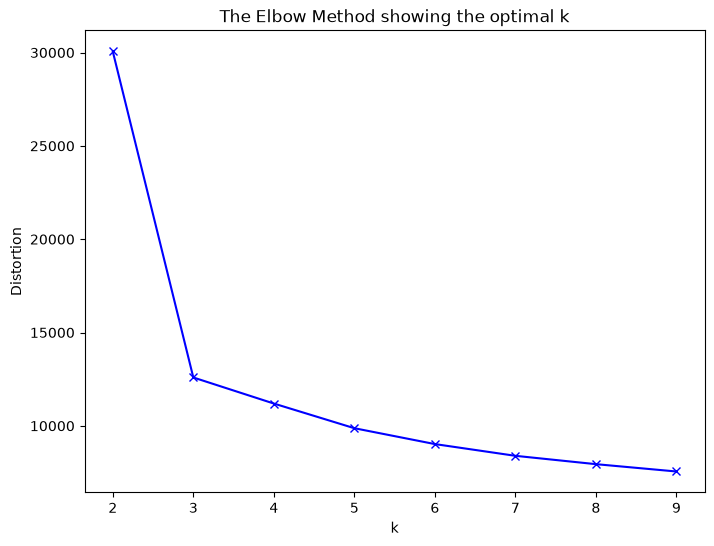

In [34]:
# Create plot for elbow method to decide optimum number of clusters
distortions =[]
K = range(2,10)
for k in K:
    kmeanModel = KMeans(n_clusters=k, n_init=10)
    kmeanModel.fit(df_scaled)
    distortions.append(kmeanModel.inertia_)

plt.figure(figsize=(8,6))
plt.plot(K, distortions, 'bx-')
plt.xlabel('k')
plt.ylabel('Distortion')
plt.title('The Elbow Method showing the optimal k')
plt.show()

In [35]:
# Using elbow method, K=4 culsters are finalized

In [36]:
# Running kmeans
np.random.seed(123)
CL = KMeans(n_clusters=4)
CL.fit(df_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](4, 5)",

In [37]:
# cluster size (no. of customers in each cluster)
labels = CL.labels_
cluster_sizes = np.bincount(labels)
print(cluster_sizes)

[8051 7895 4073 4000]


In [40]:
# add cluster membership to the data 
segment = pd.DataFrame({'segment': labels})
custsales = pd.concat([custsales_cl.reset_index(drop=True), segment], axis=1)
custsales['segment']=custsales['segment']+1
custsales.head()

,Age,BillAmt_Product,BillAmt_Service,BillAmt_Pre,Vintage,segment
0,49,81128.27,48203.10,62975.45,5.0,2
1,34,59480.20,17263.19,23633.58,5.0,4
2,58,65363.07,30660.67,45888.87,6.0,2
3,48,84073.28,47181.46,43186.04,7.0,2
4,26,10541.03,3550.96,12753.15,1.0,1


In [49]:
# calculate mean of each variable culsterwise
seg_analysis = custsales.groupby('segment')[['Age', 'BillAmt_Product','BillAmt_Service', 'BillAmt_Pre', 'Vintage']].mean().reset_index().round(2)
seg_analysis

,segment,Age,BillAmt_Product,BillAmt_Service,BillAmt_Pre,Vintage
0,1,26.99,12576.65,3761.71,12575.10,1.00
1,2,54.97,82354.48,40049.61,55064.95,6.50
2,3,37.28,42594.78,15992.31,30140.83,2.52
3,4,37.51,42544.33,16038.35,30257.02,4.50


In [50]:
# summarising each variables(average value) within each cluster
col_list=['Age', 'BillAmt_Product','BillAmt_Service', 'BillAmt_Pre', 'Vintage']

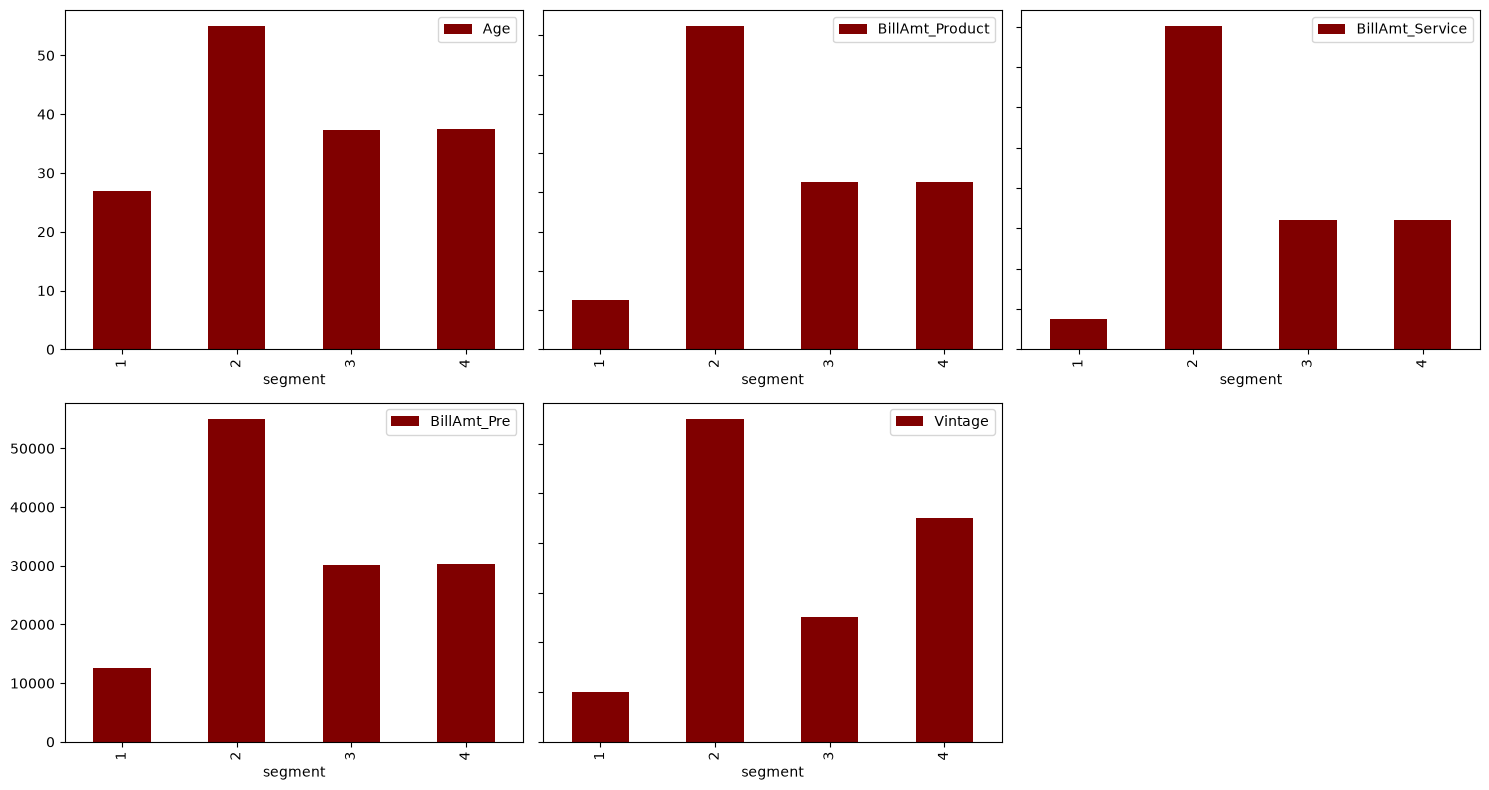

In [51]:
# create a figure
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15,8))
axe = axes.ravel()

# plot each zone on a particular axis
for i, cols in enumerate(col_list):
    seg_analysis.plot.bar('segment',cols,color = 'maroon', ax=axe[i],sharey=True)

# remove the empty subplot
fig.delaxes(axes.flatten()[5])

plt.tight_layout()
plt.show()

In [ ]:
# Comment: 
# Segment no.2 is made up of platinum customers who have greater bill amounts, also customer in this segment older and have been conducting business with the company for a longer period of time
# The customer in segment 1 are yong and have been in business with company for just been one year